In [109]:
# Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt
from collections import deque

In [110]:
class TurretEnv:
    """
    Minimal RL-style environment wrapper around Simulator.

    API:
      - obs = env.reset()
      - obs, reward, done, info = env.step(action)

    Where:
      - obs: normalized feature vector from Simulator.get_model_input()
      - action: np.array([target_yaw, target_pitch, time_to_fire])
                (radians, radians, seconds)
    """

    def __init__(
        self,
        dt: float = 0.015,
        max_steps: int = 500,
        action_is_delta: bool = False,
        action_is_correction: bool = False,
        correction_baseline: str = "panel",
        correction_clip_yaw: float | None = float(np.deg2rad(30.0)),
        correction_clip_pitch: float | None = float(np.deg2rad(15.0)),
        maintain_fire_timer: bool = True,
        lost_done_steps: int = 150,
        lost_penalty_base: float = -200.0,
        lost_penalty_slope: float = -20.0,
        lost_penalty_cap_steps: int = 50,
        lost_terminal_penalty: float = -5000.0,
        shot_base_penalty: float = 10.0,
        shot_miss_penalty_scale: float = 20.0,
        shot_miss_target_radius_mm: float = 60.0,
        shot_miss_penalty_power: float = 1.0,
        shot_miss_max_ratio: float = 5.0,
        shot_miss_max_angle_deg: float = 45.0,
        # Alignment reward shaping (camera following ideal lead angle).
        # - Bonus term uses a linear "align score" that drops to 0 beyond `align_angle_scale_deg`.
        # - Punishment term uses a smooth quadratic/quartic penalty on angular error.
        align_bonus_scale: float = 25.0,
        align_penalty_coeff: float = 600.0,
        # Lower power makes small angle errors hurt more immediately.
        align_penalty_power: float = 1.0,
        align_angle_scale_deg: float = 45.0,
        seed: int | None = None,
    ):
        self.dt = dt
        self.max_steps = max_steps
        self.action_is_delta = action_is_delta
        self.action_is_correction = action_is_correction
        self.correction_baseline = correction_baseline
        self.correction_clip_yaw = None if correction_clip_yaw is None else float(correction_clip_yaw)
        self.correction_clip_pitch = None if correction_clip_pitch is None else float(correction_clip_pitch)
        self.maintain_fire_timer = maintain_fire_timer
        # Softer penalties for initial RL debugging
        self.lost_done_steps = int(lost_done_steps)
        self.lost_penalty_base = -20.0
        self.lost_penalty_slope = -5.0
        self.lost_penalty_cap_steps = int(lost_penalty_cap_steps)
        self.lost_terminal_penalty = -200.0
        self.shot_base_penalty = 0.0
        self.shot_miss_penalty_scale = 2.0
        self.shot_miss_target_radius_mm = float(shot_miss_target_radius_mm)
        self.shot_miss_penalty_power = float(shot_miss_penalty_power)
        self.shot_miss_max_ratio = float(shot_miss_max_ratio)
        self.shot_miss_max_angle_deg = float(shot_miss_max_angle_deg)
        self.align_bonus_scale = 25.0
        self.align_penalty_coeff = 100.0
        self.align_penalty_power = float(align_penalty_power)
        self.align_angle_scale_deg = float(align_angle_scale_deg)
        self.seed = None if seed is None else int(seed)

        # Scaling constants for normalization
        self.max_distance = float(np.sqrt(WIDTH * WIDTH + HEIGHT * HEIGHT))
        self.speed_scale = 23000.0  # mm/s, rough scale for projectile speed

        self.sim: Simulator | None = None
        self.steps = 0
        self.prev_hit_count = 0
        self.prev_shots_fired = 0
        self.lost_steps = 0  # how many consecutive steps target has been off-screen
        self._time_to_fire_remaining: float | None = None
        self._prev_d_theta = 0.0
        self._prev_d_pitch = 0.0

    # ------------------------------------------------------------------
    # Core API
    # ------------------------------------------------------------------
    def reset(self, seed: int | None = None) -> np.ndarray:
        """Reset the simulation and return the initial observation."""
        if seed is None:
            seed = self.seed
        if seed is not None:
            # Simulator uses both Python's `random` and NumPy RNG.
            random.seed(int(seed))
            np.random.seed(int(seed))
        self.sim = Simulator()
        self.steps = 0
        self.prev_hit_count = 0
        self.prev_shots_fired = 0
        self.lost_steps = 0
        self._time_to_fire_remaining = None
        self._prev_d_theta = 0.0
        self._prev_d_pitch = 0.0
        return self._get_obs()

    def step(self, action: np.ndarray):
        """
        Advance the environment by one step using the given action.

        action: np.array([a0, a1, time_to_fire_cmd])
          - Default (action_is_delta=False and action_is_correction=False):
              a0/a1 are absolute targets:
                - a0: desired camera yaw (radians, world frame)
                - a1: desired camera pitch (radians)
          - If action_is_delta=True:
              a0/a1 are incremental offsets applied to the current camera pose:
                - target_yaw = camera_yaw + a0
                - target_pitch = camera_pitch + a1
          - If action_is_correction=True:
              a0/a1 are corrections applied to a per-step non-ML baseline:
                - baseline is recomputed every step
                - correction_baseline="panel" uses yaw/pitch-to-target-panel
                - target_yaw = baseline_yaw + a0
                - target_pitch = baseline_pitch + a1
          - time_to_fire_cmd: time until firing (seconds).
              This is a continuous *time-to-fire in seconds* (not a probability).
              - If maintain_fire_timer=True (default): this value arms the
                robot's internal countdown timer (if not already armed).
                The timer then counts down by dt each step and fires when <= 0.
              - If maintain_fire_timer=False: this value is treated as
                "time until firing relative to now" for *this step only*;
                when <= 0 a projectile will be fired this step.
        """
        if self.sim is None:
            raise RuntimeError("Call reset() before step().")

        if action.shape[0] != 3:
            raise ValueError("Action must have shape (3,), got %s" % (action.shape,))

        a0_raw = float(action[0])
        a1_raw = float(action[1])
        a0 = a0_raw
        a1 = a1_raw
        if self.action_is_delta and self.action_is_correction:
            raise ValueError("Choose only one of action_is_delta or action_is_correction.")

        baseline_yaw = None
        baseline_pitch = None
        if self.action_is_correction:
            if self.correction_clip_yaw is not None:
                a0 = float(np.clip(a0, -self.correction_clip_yaw, self.correction_clip_yaw))
            if self.correction_clip_pitch is not None:
                a1 = float(np.clip(a1, -self.correction_clip_pitch, self.correction_clip_pitch))
            if self.correction_baseline == "panel":
                raw = self.sim.get_model_input()
                baseline_yaw = float(raw[2])
                baseline_pitch = float(raw[3])
            else:
                raise ValueError(
                    "Unknown correction_baseline=%r (expected 'panel')." % (self.correction_baseline,)
                )
            target_yaw = float(baseline_yaw + a0)
            target_pitch = float(baseline_pitch + a1)
        elif self.action_is_delta:
            target_yaw = float(self.sim.camera.theta + a0)
            target_pitch = float(self.sim.camera.pitch + a1)
        else:
            target_yaw = a0
            target_pitch = a1
        time_to_fire_cmd = float(action[2])

        # Match real robot behavior: maintain a countdown timer internally.
        # This allows the policy to set a time-to-fire once and have it count down.
        if self.maintain_fire_timer:
            if self._time_to_fire_remaining is None:
                self._time_to_fire_remaining = time_to_fire_cmd

            # Countdown occurs in real time regardless of action updates.
            self._time_to_fire_remaining -= self.dt
            time_to_fire = self._time_to_fire_remaining
        else:
            time_to_fire = time_to_fire_cmd

        # Advance the simulator with model outputs
        shots_before = self.sim.shots_fired
        self.sim.step_with_model_output(self.dt, target_yaw, target_pitch, time_to_fire)
        if self.maintain_fire_timer and self.sim.shots_fired > shots_before:
            # Reset so the next shot requires re-arming the timer.
            self._time_to_fire_remaining = None
        self.steps += 1

        obs = self._get_obs()
        reward = self._compute_reward()
        done = self._is_done()
        info = {
            "hit_count": self.sim.hit_count,
            "total_time": self.sim.total_time,
            "opportunity_time": self.sim.opportunity_time,
            "ideal_alignment_time": self.sim.ideal_alignment_time,
            "target_yaw": float(target_yaw),
            "target_pitch": float(target_pitch),
            "last_shot_visible_panel_count": int(getattr(self.sim, "last_shot_visible_panel_count", 0) or 0),
        }
        if self.action_is_correction:
            info.update(
                {
                    "baseline_yaw": float(baseline_yaw) if baseline_yaw is not None else None,
                    "baseline_pitch": float(baseline_pitch) if baseline_pitch is not None else None,
                    "correction_yaw_raw": float(a0_raw),
                    "correction_pitch_raw": float(a1_raw),
                    "correction_yaw_applied": float(a0),
                    "correction_pitch_applied": float(a1),
                }
            )

        return obs, reward, done, info

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------
    def _get_obs(self) -> np.ndarray:
        """
        Fetch and normalize the model input features from the simulator.

        Raw features from Simulator.get_model_input():
          [camera_yaw,
           camera_pitch,
           yaw_to_panel,
           pitch_to_panel,
           panel_yaw_world,
           distance_to_panel_mm,
           projectile_speed_mm_per_s]

        Normalization:
          - All angles divided by pi  -> approx in [-1, 1]
          - Distance divided by max_distance
          - Speed divided by speed_scale
        """
        raw = self.sim.get_model_input()

        camera_yaw = raw[0] / np.pi
        camera_pitch = raw[1] / np.pi
        yaw_to_panel = raw[2] / np.pi
        pitch_to_panel = raw[3] / np.pi
        panel_yaw_world = raw[4] / np.pi

        distance = raw[5] / max(self.max_distance, 1e-6)
        projectile_speed = raw[6] / self.speed_scale

        obs = np.array(
            [
                camera_yaw,
                camera_pitch,
                yaw_to_panel,
                pitch_to_panel,
                panel_yaw_world,
                distance,
                projectile_speed,
            ],
            dtype=np.float32,
        )
        return obs

    def _compute_reward(self) -> float:
        """
        Combine hit-based reward with alignment-based shaping.
        """
        # Hit reward: positive reward when new hits occur
        hit_inc = self.sim.hit_count - self.prev_hit_count
        self.prev_hit_count = self.sim.hit_count
        r_hit = 110.0 * hit_inc

        # Shot penalty: small negative reward for each projectile fired
        shots_inc = self.sim.shots_fired - self.prev_shots_fired
        self.prev_shots_fired = self.sim.shots_fired
        # Penalize firing, and add an extra miss-distance penalty based on aim error
        # at the instant the shot is fired (dense learning signal).
        r_shot_base = -self.shot_base_penalty * shots_inc
        r_shot_miss = 0.0
        r_blind_fire = 0.0
        if shots_inc > 0:
            visible_cnt = int(getattr(self.sim, "last_shot_visible_panel_count", 0) or 0)
            if visible_cnt <= 0:
                # In the real system you shouldn't be able to score hits on an unseen panel.
                # Strongly discourage firing when no valid target is visible.
                r_blind_fire = -500.0 * shots_inc
            elif self.shot_miss_penalty_scale != 0.0:
                ideal_yaw = getattr(self.sim, "ideal_yaw", None)
                ideal_pitch = getattr(self.sim, "ideal_pitch", None)
                if ideal_yaw is not None and ideal_pitch is not None:
                    yaw_err = np.arctan2(
                        np.sin(float(ideal_yaw) - float(self.sim.camera.theta)),
                        np.cos(float(ideal_yaw) - float(self.sim.camera.theta)),
                    )
                    pitch_err = float(ideal_pitch) - float(self.sim.camera.pitch)
                    angle_err = float(np.sqrt(yaw_err * yaw_err + pitch_err * pitch_err))
                    max_angle_rad = float(np.deg2rad(max(1e-6, self.shot_miss_max_angle_deg)))
                    angle_err = float(np.clip(angle_err, 0.0, max_angle_rad))

                    raw = self.sim.get_model_input()
                    try:
                        distance_mm = float(raw[5])
                    except Exception:
                        distance_mm = 0.0

                    # Approximate lateral miss distance from angular error.
                    miss_mm = float(distance_mm * np.tan(angle_err))
                    denom = max(float(self.shot_miss_target_radius_mm), 1e-6)
                    ratio = miss_mm / denom
                    ratio = float(np.clip(ratio, 0.0, max(0.0, self.shot_miss_max_ratio)))
                    power = max(float(self.shot_miss_penalty_power), 1e-6)
                    r_shot_miss = -self.shot_miss_penalty_scale * (ratio**power) * shots_inc

        # Alignment reward: encourage camera to track ideal lead angle
        r_align = 0.0
        if self.sim.ideal_yaw is not None:
            yaw_err = np.arctan2(
                np.sin(self.sim.ideal_yaw - self.sim.camera.theta),
                np.cos(self.sim.ideal_yaw - self.sim.camera.theta),
            )
            pitch_err = float(self.sim.ideal_pitch - self.sim.camera.pitch)
            angle_err = float(abs(yaw_err) + abs(pitch_err))

            # Following ideal/predicted line:
            # - bonus drops linearly with error up to `align_angle_scale_deg`
            # - penalty grows smoothly with a stronger power on error
            angle_scale = np.deg2rad(max(self.align_angle_scale_deg, 1e-6))
            align_score = max(0.0, 1.0 - angle_err / max(float(angle_scale), 1e-6))
            r_align = (
                self.align_bonus_scale * float(align_score)
                - self.align_penalty_coeff * (angle_err**self.align_penalty_power)
            )

        # Tracking reward: strongly encourage keeping the target panel in view.
        # If the chosen target panel is visible, reward staying locked on it.
        # If it is lost (off-screen), give a strong penalty and track how long
        # it has been lost.
        r_track = 0.0
        target_panel = self.sim._get_target_panel()
        if target_panel is not None and target_panel.visible:
            # Positive reward every step the target remains visible.
            r_track = 50.0
            self.lost_steps = 0
        else:
            self.lost_steps += 1
            # Softer (non-cliff) shaping: small penalty when first lost,
            # increasing with consecutive lost steps, plus a terminal penalty
            # when the episode ends due to being lost too long.
            capped = min(self.lost_steps, self.lost_penalty_cap_steps)
            r_track = self.lost_penalty_base + self.lost_penalty_slope * capped
            if self.lost_steps >= self.lost_done_steps:
                r_track += self.lost_terminal_penalty

        # Camera motion penalty: discourages rapid side-switching / jitter.
        d_theta = float(getattr(self.sim, "last_d_theta", 0.0))
        d_pitch = float(getattr(self.sim, "last_d_pitch", 0.0))
        r_motion = -50.0 * (abs(d_theta) + abs(d_pitch))

        jerk = abs(d_theta - self._prev_d_theta) + abs(d_pitch - self._prev_d_pitch)
        r_jerk = -200.0 * jerk
        self._prev_d_theta = d_theta
        self._prev_d_pitch = d_pitch

        return float(
            r_hit
            + r_shot_base
            + r_shot_miss
            + r_blind_fire
            + r_align
            + r_track
            + r_motion
            + r_jerk
        )

    def _is_done(self) -> bool:
        """Episode termination condition."""
        if self.steps >= self.max_steps:
            return True

        # Terminate if robot leaves the world bounds
        robot = self.sim.robot
        if robot.x < 0 or robot.x > WIDTH or robot.y < 0 or robot.y > HEIGHT:
            return True

        # If the target has been off-screen for too long, end the episode.
        # This teaches the agent that losing the robot is a terminal failure.
        if self.lost_steps >= self.lost_done_steps:
            return True

        return False

    def render(self):
        """Render the underlying simulator debug view."""
        if self.sim is not None:
            self.sim.render()


In [111]:
import numpy as np
import random
import time

# Coordinate system and units:
# - All distances are in millimeters (mm)
# - Velocities are in mm/s
# - Accelerations are in mm/s^2
# - Time is in seconds

WIDTH = 12000          # mm
HEIGHT = 12000         # mm
DEBUG = False

GRAVITY = -9800.0     # mm/s^2, downward acceleration

MAX_VEL = 4000        # mm/s
MAX_OMEGA = 6.0       # rad/s (caps angular velocity)
MAX_OMEGA_ACC = 25.0  # rad/s^2 (caps angular acceleration kicks)
OMEGA_ACC_TAU = 0.6   # seconds, time constant for accel decay (smaller => more variation)
OMEGA_ACC_SIGMA = 12.0 # rad/s^2 * sqrt(s) noise strength for accel drift


class Panel:
    def __init__(self, z_offset, base_theta):
        self.base_theta = base_theta
        self.z_offset = z_offset
        self.x = 0
        self.y = 0
        self.z = 0
        self.visible = False


class Camera:
    def __init__(self):
        self.x = WIDTH / 2
        self.y = HEIGHT / 2
        self.z = 0
        self.theta = np.deg2rad(-90)  # initial orientation
        self.pitch = 0.0  # 0 = level, negative = down
        self.fov = np.deg2rad(60)


class Robot:
    def __init__(self, radius, camera):
        # Randomize start away from camera
        self.radius = radius
        self.x, self.y = self._random_start_position(camera, min_dist=300)
        self.z = 0

        self.vx = 0.0
        self.vy = 0.0
        self.ax = 0.0
        self.ay = 0.0

        # Randomize initial velocities so trajectories vary from the first step.
        self.vx = random.uniform(-0.5 * MAX_VEL, 0.5 * MAX_VEL)
        self.vy = random.uniform(-0.5 * MAX_VEL, 0.5 * MAX_VEL)

        self.theta = 0.0
        self.omega = random.uniform(-0.5 * MAX_OMEGA, 0.5 * MAX_OMEGA)
        self.omega_acc = random.uniform(-0.25 * MAX_OMEGA_ACC, 0.25 * MAX_OMEGA_ACC)
        self._time = 0.0

        # Panels are offset vertically from the robot center (mm)
        height1 = random.uniform(-30.0, -10.0)
        height2 = random.uniform(-30.0, -10.0)

        self.panels = [
            Panel(height1, np.deg2rad(0)),
            Panel(height2, np.deg2rad(180)),
            Panel(height1, np.deg2rad(90)),
            Panel(height2, np.deg2rad(270)),
        ]

        self.update_panels(camera)

    def _random_start_position(self, camera, min_dist=300.0):
        while True:
            x = random.uniform(self.radius, WIDTH - self.radius)
            y = random.uniform(self.radius, HEIGHT - self.radius)
            dx = x - camera.x
            dy = y - camera.y
            if np.hypot(dx, dy) >= min_dist:
                return x, y

    def update_panels(self, camera):
        for panel in self.panels:
            theta = self.theta + panel.base_theta
            panel.x = self.x + self.radius * np.cos(theta)
            panel.y = self.y + self.radius * np.sin(theta)
            panel.z = self.z + panel.z_offset

            # Vector from camera to panel
            dx = panel.x - camera.x
            dy = panel.y - camera.y
            angle_to_panel = np.arctan2(dy, dx)
            relative_angle = angle_to_panel - camera.theta
            relative_angle = np.arctan2(np.sin(relative_angle), np.cos(relative_angle))

            in_fov = abs(relative_angle) <= camera.fov / 2

            # Panel outward normal
            nx = np.cos(theta)
            ny = np.sin(theta)

            # Direction from panel to camera
            vx = camera.x - panel.x
            vy = camera.y - panel.y
            facing_camera = (nx * vx + ny * vy) > 0

            panel.visible = in_fov and facing_camera

    def update(self, dt, camera):
        self._time += float(dt)

        # Occasional maneuver
        if random.random() < 0.05:
            self.ax = random.uniform(-750.0, 750.0)
            self.ay = random.uniform(-750.0, 750.0)
            # Instead of reassigning angular velocity directly, kick angular acceleration.
            self.omega_acc = random.uniform(-MAX_OMEGA_ACC, MAX_OMEGA_ACC)

        # Velocity update
        self.vx += self.ax * dt
        self.vy += self.ay * dt

        # Limit velocities
        self.vx = np.clip(self.vx, -MAX_VEL, MAX_VEL)
        self.vy = np.clip(self.vy, -MAX_VEL, MAX_VEL)

        # Position update
        self.x += self.vx * dt + 0.5 * self.ax * dt * dt
        self.y += self.vy * dt + 0.5 * self.ay * dt * dt

        # Rotation
        # Angular acceleration changes over time, then integrates into omega and theta.
        #
        # OU-style drift keeps omega_acc correlated over time.
        decay = float(dt) / max(float(OMEGA_ACC_TAU), 1e-6)
        self.omega_acc += (-self.omega_acc) * decay
        self.omega_acc += OMEGA_ACC_SIGMA * (np.sqrt(float(dt)) * np.random.normal())

        self.omega += self.omega_acc * dt
        self.omega = float(np.clip(self.omega, -MAX_OMEGA, MAX_OMEGA))

        self.theta += self.omega * dt

        self.update_panels(camera)
        self.avoid_camera(camera, min_dist=300)  # Prevent moving into camera

    def avoid_camera(self, camera, min_dist=300.0):
        dx = self.x - camera.x
        dy = self.y - camera.y
        dist = np.hypot(dx, dy)

        if dist < min_dist:
            # Push robot outside the minimum distance
            angle = np.arctan2(dy, dx)
            self.x = camera.x + min_dist * np.cos(angle)
            self.y = camera.y + min_dist * np.sin(angle)

            # Remove velocity towards the camera
            v_radial = self.vx * np.cos(angle) + self.vy * np.sin(angle)
            if v_radial < 0:
                self.vx -= v_radial * np.cos(angle)
                self.vy -= v_radial * np.sin(angle)

class Projectile:
    def __init__(self, x, y, z, theta, pitch, speed, allowed_panel_indices=()):
        self.x = x
        self.y = y
        self.z = z
        # Decompose speed into horizontal and vertical using pitch
        horiz_speed = speed * np.cos(pitch)
        self.vx = horiz_speed * np.cos(theta)
        self.vy = horiz_speed * np.sin(theta)
        self.vz = speed * np.sin(pitch)
        self.alive = True
        # Panels that were visible (in-FOV and facing camera) when this shot was fired.
        # Hits on panels not in this set are ignored to match "must be seen to shoot".
        self.allowed_panel_indices = tuple(int(i) for i in allowed_panel_indices)

    def update(self, dt):
        if not self.alive:
            return

        # Integrate velocity with gravity in z
        self.vz += GRAVITY * dt
        self.x += self.vx * dt
        self.y += self.vy * dt
        self.z += self.vz * dt

        # Kill projectile if it leaves the world bounds or falls too far below
        if (
            self.x < 0
            or self.x > WIDTH
            or self.y < 0
            or self.y > HEIGHT
            or self.z < -20000
        ):
            self.alive = False


class Simulator:
    def __init__(self):
        self.camera = Camera()
        radius = random.randint(150, 250)
        self.robot = Robot(radius, self.camera)
        self.projectiles = []
        self.projectile_speed = 23000.0  # mm/s
        # Latest applied camera increments (after rate limiting).
        self.last_d_theta = 0.0
        self.last_d_pitch = 0.0

        # Scoring / metrics
        self.total_time = 0.0
        self.opportunity_time = 0.0  # time robot is within FOV (current center)
        self.ideal_alignment_time = 0.0  # time camera is near ideal lead angle
        self.hit_count = 0
        self.shots_fired = 0  # total number of projectiles spawned
        self.last_shot_visible_panel_indices = ()
        self.last_shot_visible_panel_count = 0

        # For estimating relative velocity of the robot center (camera-centered)
        self._prev_rel_center = None

        # Store latest ideal lead direction for debugging visualization
        self.ideal_yaw = None
        self.ideal_pitch = None

        # Aim camera so that the robot starts somewhere inside the FOV cone,
        # but not perfectly centered every time.
        dx = self.robot.x - self.camera.x
        dy = self.robot.y - self.camera.y
        base_yaw = np.arctan2(dy, dx)
        # Random offset so robot is somewhere within the cone, not dead center
        yaw_offset = random.uniform(-self.camera.fov / 4, self.camera.fov / 4)
        self.camera.theta = base_yaw + yaw_offset

    @staticmethod
    def _ballistic_pitch_for_point(horiz_dist: float, z: float, speed: float, gravity: float):
        """
        Solve for a launch pitch angle (radians) to hit a point at (R, z)
        with initial speed `speed` under constant vertical acceleration `gravity`.

        Conventions:
          - gravity should be negative (e.g., -9800 mm/s^2).
          - Positive pitch shoots upward.

        Returns:
          - pitch (float) if a real solution exists, else None.
        """
        R = float(horiz_dist)
        if R <= 1e-6 or speed <= 1e-6:
            return None
        g = float(gravity)
        if g >= 0.0:
            return None

        g_abs = -g
        v2 = speed * speed

        # From projectile motion: z = R*tan(a) - (g_abs * R^2)/(2*v^2*cos^2(a))
        # Solve quadratic in tan(a):
        # tan(a) = (v^2 ± sqrt(v^4 - g_abs*(g_abs*R^2 + 2*z*v^2))) / (g_abs*R)
        disc = v2 * v2 - g_abs * (g_abs * R * R + 2.0 * z * v2)
        if disc < 0.0:
            return None

        sqrt_disc = float(np.sqrt(disc))
        denom = g_abs * R
        if denom <= 1e-12:
            return None

        tan1 = (v2 + sqrt_disc) / denom
        tan2 = (v2 - sqrt_disc) / denom
        cand = [float(np.arctan(tan1)), float(np.arctan(tan2))]

        max_pitch = float(np.deg2rad(89))
        cand = [a for a in cand if np.isfinite(a) and -max_pitch <= a <= max_pitch]
        if not cand:
            return None

        # Prefer the smaller-magnitude pitch (typically the lower/straighter arc).
        return min(cand, key=lambda a: abs(a))

    def _get_target_panel(self):
        """
        Select a single target panel for the model to track.
        Preference is given to the closest visible panel; if none
        are visible, fall back to the closest panel in 3D distance.
        """
        closest_visible = None
        closest_visible_dist = float("inf")
        closest_any = None
        closest_any_dist = float("inf")

        for panel in self.robot.panels:
            dx = panel.x - self.camera.x
            dy = panel.y - self.camera.y
            dz = panel.z - self.camera.z
            dist = np.sqrt(dx * dx + dy * dy + dz * dz)

            if dist < closest_any_dist:
                closest_any_dist = dist
                closest_any = panel

            if panel.visible and dist < closest_visible_dist:
                closest_visible_dist = dist
                closest_visible = panel

        return closest_visible if closest_visible is not None else closest_any

    def fire_projectile(self):
        visible_indices = tuple(i for i, p in enumerate(self.robot.panels) if p.visible)
        self.last_shot_visible_panel_indices = visible_indices
        self.last_shot_visible_panel_count = len(visible_indices)
        # Spawn a projectile from the camera along its current heading
        proj = Projectile(
            self.camera.x,
            self.camera.y,
            self.camera.z,
            self.camera.theta,
            self.camera.pitch,
            self.projectile_speed,
            allowed_panel_indices=visible_indices,
        )
        self.projectiles.append(proj)
        self.shots_fired += 1

    def _update_projectiles(self, dt, hit_tol_mm=100.0):
        alive_projectiles = []
        for proj in self.projectiles:
            proj.update(dt)
            if not proj.alive:
                continue

            hit = False
            for idx, panel in enumerate(self.robot.panels):
                if proj.allowed_panel_indices and idx not in proj.allowed_panel_indices:
                    continue
                # 3D positional tolerance check (sphere of radius hit_tol_mm)
                dx = proj.x - panel.x
                dy = proj.y - panel.y
                dz = proj.z - panel.z
                dist = np.sqrt(dx * dx + dy * dy + dz * dz)
                if dist <= hit_tol_mm:
                    hit = True
                    if DEBUG:
                        print("hit")
                    self.hit_count += 1
                    break

            if not hit:
                alive_projectiles.append(proj)

        self.projectiles = alive_projectiles

    def step(self, dt, d_theta=0.0, d_pitch=0.0):
        # Camera control is now owned by the agent (RL policy).
        # d_theta, d_pitch are incremental changes per step.
        d_theta = float(d_theta)
        d_pitch = float(d_pitch)
        self.last_d_theta = d_theta
        self.last_d_pitch = d_pitch
        self.camera.theta += d_theta
        self.camera.pitch += d_pitch
        # Keep yaw bounded to avoid wrap discontinuities in downstream code.
        self.camera.theta = np.arctan2(np.sin(self.camera.theta), np.cos(self.camera.theta))

        # Optional: clamp pitch to a reasonable range (e.g., ±90 degrees)
        max_pitch = np.deg2rad(89)
        self.camera.pitch = np.clip(self.camera.pitch, -max_pitch, max_pitch)

        # Update robot state
        self.robot.update(dt, self.camera)
        self._update_projectiles(dt)

        # Update scoring metrics
        # Camera-centered robot center
        rel_x = self.robot.x - self.camera.x
        rel_y = self.robot.y - self.camera.y
        rel_z = self.robot.z - self.camera.z

        # Estimate relative velocity via finite differences
        if self._prev_rel_center is not None and dt > 0:
            vx = (rel_x - self._prev_rel_center[0]) / dt
            vy = (rel_y - self._prev_rel_center[1]) / dt
            vz = (rel_z - self._prev_rel_center[2]) / dt
        else:
            vx = vy = vz = 0.0
        self._prev_rel_center = (rel_x, rel_y, rel_z)

        # Track total simulated time
        self.total_time += dt

        # "Opportunity" time: robot center currently within camera FOV in yaw
        center_yaw = np.arctan2(rel_y, rel_x)
        yaw_err_current = np.arctan2(
            np.sin(center_yaw - self.camera.theta),
            np.cos(center_yaw - self.camera.theta),
        )
        if abs(yaw_err_current) <= self.camera.fov / 2:
            self.opportunity_time += dt

        # Ideal lead direction toward future robot center based on simple intercept
        # approximation (gravity is included in ideal pitch).
        p = np.array([rel_x, rel_y, rel_z], dtype=float)
        v = np.array([vx, vy, vz], dtype=float)
        p_norm = np.linalg.norm(p)
        if p_norm > 1e-6 and self.projectile_speed > 1e-6:
            T = p_norm / self.projectile_speed
            # A couple of fixed-point refinement steps for T
            for _ in range(2):
                future_pos = p + v * T
                dist_future = np.linalg.norm(future_pos)
                if dist_future < 1e-6:
                    break
                T = dist_future / self.projectile_speed

            future_pos = p + v * T
            fx, fy, fz = future_pos
            horiz_dist = np.hypot(fx, fy)
            ideal_yaw = np.arctan2(fy, fx)
            ideal_pitch = self._ballistic_pitch_for_point(
                horiz_dist=horiz_dist,
                z=fz,
                speed=self.projectile_speed,
                gravity=GRAVITY,
            )
            if ideal_pitch is None:
                # Fall back to straight-line pitch if no ballistic solution exists.
                ideal_pitch = np.arctan2(fz, horiz_dist)

            # Store for debug drawing
            self.ideal_yaw = ideal_yaw
            self.ideal_pitch = ideal_pitch

            # Angular error between camera orientation and ideal lead angle
            yaw_err_ideal = np.arctan2(
                np.sin(ideal_yaw - self.camera.theta),
                np.cos(ideal_yaw - self.camera.theta),
            )
            pitch_err_ideal = ideal_pitch - self.camera.pitch

            # Count time when camera is well aligned with the ideal lead direction
            yaw_thresh = np.deg2rad(3.0)
            pitch_thresh = np.deg2rad(3.0)
            if abs(yaw_err_ideal) <= yaw_thresh and abs(pitch_err_ideal) <= pitch_thresh:
                self.ideal_alignment_time += dt

        # Default return (can be replaced by higher-level RL env wrapper)
        return None

    def get_model_input(self):
        """
        Return a compact feature vector for the model based on the
        current state and a single target panel.

        Features (all scalars):
        - camera_yaw
        - camera_pitch
        - yaw_to_panel        (global yaw from camera to panel)
        - pitch_to_panel      (global pitch from camera to panel)
        - panel_yaw_world     (panel outward normal yaw in world frame)
        - distance_to_panel   (3D distance, mm)
        - projectile_speed    (mm/s)
        """
        target = self._get_target_panel()
        if target is None:
            # No panels (should not happen), return zeros
            return np.zeros(7, dtype=float)

        # Relative position from camera to panel (mm)
        rel_x = target.x - self.camera.x
        rel_y = target.y - self.camera.y
        rel_z = target.z - self.camera.z

        horiz_dist = np.hypot(rel_x, rel_y)
        distance = np.sqrt(rel_x * rel_x + rel_y * rel_y + rel_z * rel_z)

        # Global yaw/pitch from camera to panel
        yaw_to_panel = np.arctan2(rel_y, rel_x)
        pitch_to_panel = np.arctan2(rel_z, horiz_dist) if horiz_dist > 1e-6 else 0.0

        # Panel outward normal yaw (world), then relative to camera yaw
        # Recompute panel orientation the same way as in update_panels.
        theta_panel = self.robot.theta + target.base_theta
        panel_yaw_world = np.arctan2(np.sin(theta_panel), np.cos(theta_panel))

        features = np.array(
            [
                self.camera.theta,
                self.camera.pitch,
                yaw_to_panel,
                pitch_to_panel,
                panel_yaw_world,
                distance,
                self.projectile_speed,
            ],
            dtype=float,
        )
        return features

    def step_with_model_output(self, dt, target_yaw, target_pitch, time_to_fire):
        """
        Convenience helper for RL / RNN inference.

        The model outputs:
        - target_yaw: desired camera yaw (rad, world frame)
        - target_pitch: desired camera pitch (rad)
        - time_to_fire: predicted time until firing (seconds, relative to *now*; not a probability)

        This helper:
        - Converts (target_yaw, target_pitch) into incremental deltas
          for this step and advances the simulation.
        - If time_to_fire <= 0, it also fires a projectile.

        Note: managing the countdown of time_to_fire across steps
        (e.g., subtracting dt each loop) is the caller's responsibility.
        """
        # Smallest-angle difference for yaw
        d_theta = np.arctan2(
            np.sin(target_yaw - self.camera.theta),
            np.cos(target_yaw - self.camera.theta),
        )
        d_pitch = target_pitch - self.camera.pitch

        self.step(dt, d_theta=d_theta, d_pitch=d_pitch)

        if time_to_fire <= 0.0:
            self.fire_projectile()

    def observe(self, noise=True):
        obs = []
        for panel in self.robot.panels:
            # Express panel positions in a camera-centered frame so that
            # the origin (0, 0, 0) is at the camera position.
            x = panel.x - self.camera.x
            y = panel.y - self.camera.y
            z = panel.z - self.camera.z
            if noise:
                x += np.random.normal(0, 2)
                y += np.random.normal(0, 2)
                z += np.random.normal(0, 1)
            obs.append([x, y, z])
        return np.array(obs)

    def render(self):
        """Render disabled for Kaggle compatibility."""
        pass

In [112]:
# Constants
OBS_DIM = 7  # Observation dimensions (yaw, pitch, distance, etc.)
ACTION_DIM = 3  # Action dimensions (yaw, pitch, time_to_fire)
HIDDEN_DIM = 128  # GRU hidden layer size
LEARNING_RATE = 1e-4  # Learning rate for optimizer
GAMMA = 0.99  # Discount factor for rewards
BATCH_SIZE = 32  # Batch size for training
MAX_EPISODES = 1000  # Maximum number of episodes
MAX_STEPS = 500  # Maximum steps per episode
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [113]:
# GRU Policy Model
class GRUPolicy(nn.Module):
    def __init__(self, obs_dim, hidden_dim, action_dim):
        super(GRUPolicy, self).__init__()
        self.obs_embed = nn.Linear(obs_dim, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.action_head = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, obs_seq, hidden=None):
        x = torch.relu(self.obs_embed(obs_seq))
        out, h = self.gru(x, hidden)
        mu = self.action_head(out)
        return mu, self.log_std.exp(), h

    def sample_action(self, obs_seq, hidden=None):
        mu, std, h = self.forward(obs_seq, hidden)
        dist = Normal(mu, std)
        raw_action = dist.sample()
        log_prob = dist.log_prob(raw_action).sum(-1)
        return raw_action, log_prob, h

In [114]:
# Training Loop
def train(env, policy, optimizer, max_episodes, max_steps, gamma, best_model_path=None, current_model_path=None, save_current_every=10):
    policy.train()
    episode_rewards = []
    best_return = -float('inf')
    for episode in range(max_episodes):
        obs = env.reset()
        obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0).unsqueeze(0)
        hidden = None
        episode_reward = 0
        log_probs = []
        rewards = []

        for step in range(max_steps):
            action, log_prob, hidden = policy.sample_action(obs, hidden)
            action_np = action.squeeze(0).squeeze(0).detach().cpu().numpy()
            next_obs, reward, done, _ = env.step(action_np)

            log_probs.append(log_prob)
            rewards.append(reward)
            episode_reward += reward

            obs = torch.tensor(next_obs, dtype=torch.float32, device=DEVICE).unsqueeze(0).unsqueeze(0)

            if done:
                break

        # Compute returns and policy loss
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32, device=DEVICE)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        policy_loss = 0
        for log_prob, G in zip(log_probs, returns):
            policy_loss += -log_prob * G

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        episode_rewards.append(episode_reward)
        print(f"Episode {episode + 1}/{max_episodes}, Reward: {episode_reward}")
        if (episode+1) % 10 == 0:
            print(f"ep={episode+1} reward={episode_reward:.1f} hits={env.sim.hit_count} shots={env.sim.shots_fired}")

        # Save current model state periodically
        if current_model_path is not None and ((episode + 1) % save_current_every == 0):
            torch.save(policy.state_dict(), current_model_path)
            print(f"  [Saved current model to {current_model_path}]")

        # Track and save best model by episode return
        if best_model_path is not None and episode_reward > best_return:
            best_return = episode_reward
            torch.save(policy.state_dict(), best_model_path)
            print(f"  *** New best model at episode {episode+1} with return {best_return:.1f} -> {best_model_path} ***")

    return episode_rewards, best_return

In [115]:
# Initialize Environment and Policy
env = TurretEnv()
policy = GRUPolicy(OBS_DIM, HIDDEN_DIM, ACTION_DIM).to(DEVICE)
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)

In [116]:
# Train the Policy
from google.colab import drive
import os
drive.mount('/content/drive')

# Then update paths:
save_dir = "/content/drive/My Drive/turret_models"
os.makedirs(save_dir, exist_ok=True)
best_model_path = "/content/drive/My Drive/turret_models/notebook_best.pt"
current_model_path = "/content/drive/My Drive/turret_models/current_notebook_gru.pt"

episode_rewards, best_return = train(
    env,
    policy,
    optimizer,
    MAX_EPISODES,
    MAX_STEPS,
    GAMMA,
    best_model_path=best_model_path,
    current_model_path=current_model_path,
    save_current_every=10,
)
print(f"Training finished; best episode return = {best_return:.1f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Episode 1/1000, Reward: -500913.52450851374
  *** New best model at episode 1 with return -500913.5 -> /content/drive/My Drive/turret_models/notebook_best.pt ***
Episode 2/1000, Reward: -213030.34492552668
  *** New best model at episode 2 with return -213030.3 -> /content/drive/My Drive/turret_models/notebook_best.pt ***
Episode 3/1000, Reward: -405177.00881315186
Episode 4/1000, Reward: -49197.103860782045
  *** New best model at episode 4 with return -49197.1 -> /content/drive/My Drive/turret_models/notebook_best.pt ***
Episode 5/1000, Reward: -519654.1253258699
Episode 6/1000, Reward: -37833.618258699134
  *** New best model at episode 6 with return -37833.6 -> /content/drive/My Drive/turret_models/notebook_best.pt ***
Episode 7/1000, Reward: -286293.942430199
Episode 8/1000, Reward: -127597.94141375356
Episode 9/1000, Reward: -55080.07254235431
Episode 1

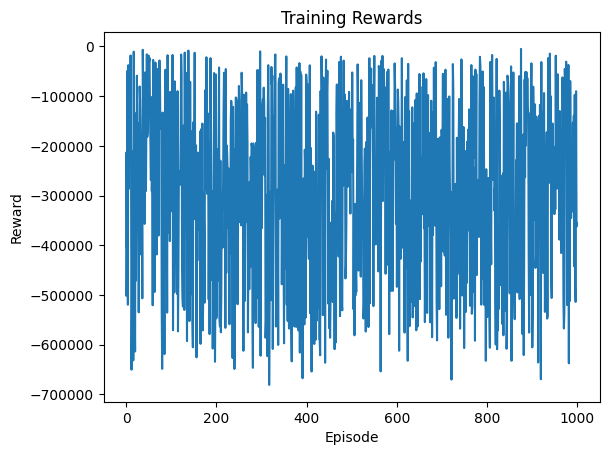

In [117]:
# Plot Training Rewards
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Rewards")
plt.show()